# **Project Name**    - **Paisabazaar Banking Fraud Analysis**




##### **Project Type**    - Exploratory Data Analysis
##### **Contribution**    - Individual

# **Project Summary -**



This project presents an exploratory data analysis (EDA) of Paisabazaar’s customer dataset to identify key factors influencing credit scores. Accurate credit score classification is crucial for financial institutions to assess risk, approve loans, and offer personalized products. The dataset contains 100,000 records and 28 features, including demographic, financial, and behavioral variables.

The analysis began with data cleaning and understanding variable distributions. Most customers had a Standard credit score, with fewer classified as Good or Poor. Univariate and bivariate analyses revealed that higher annual income, fewer bank accounts, and fewer credit cards are strongly linked to good credit scores. In contrast, high outstanding debt, high EMI per month, and high interest rates are associated with poor credit scores. Age is also a significant factor—older customers tend to have better credit scores, while younger customers are at higher risk.

Surprisingly, occupation and payment behavior showed little correlation with credit score, indicating that financial and behavioral metrics are more predictive. The data was further transformed to create a concise customer-level view, enabling more meaningful visualizations and insights.

Key recommendations for Paisabazaar include prioritizing customers with higher income and fewer credit lines, closely monitoring those with high debt and EMI, and using age and income as primary features in credit assessment models. Targeted financial advice should be offered to high-risk groups, such as younger customers or those with multiple credit cards.

In summary, this EDA provides actionable insights to help Paisabazaar refine its credit assessment process, reduce financial risk, and deliver better, data-driven recommendations to customers, supporting responsible

# **Problem Statement**


**Bussiness Problem Statement Overview.**

Accurate classification of Credit Score is very important for a financial services as it is a significant metric used by financial institutions to determine the likelihood that an individual will repay their loans or credit balances.

Paisabazaar is a financial services company that assists customers in finding and applying for various banking and credit products. An integral part of their service is assessing the creditworthiness of individuals, which is crucial for both loan approval and risk management.Paisabazaar enhance their credit assessment processes, reduce the risk of loan defaults, and offer personalized financial advice to their customers.

In this context, analyzing and classifying credit scores based on customer data can improve decision-making processes and contribute to better financial product recommendations.In this project, we will analyse customer data of a paisabazar, do exploratory data analysis to identify the main features that influence credit score of person.

#### **Define Your Business Objective?**

To identify and analyze the key factors influencing customer credit scores in order to improve credit assessment and reduce financial risk for Paisabazaar.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings

warnings.filterwarnings("ignore")

### Dataset Loading

In [3]:
# Dataset Location
link = "dataset.csv"

### Dataset First View

In [4]:
# Dataset First Look
data = pd.read_csv(link)
#to view first 5 rows of data
data.head()


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [5]:
#to view random data rows
data.sample(5)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
6937,16039,22109,2,Aruna Viswanathaq,36.0,311149969.0,Media_Manager,75672.08,6254.006667,7.0,...,Bad,3881.25,31.703159,83.0,Yes,311.884745,109.159525,Low_spent_Medium_value_payments,13.548538,Standard
57586,92012,50207,3,Kerberz,30.0,710888800.0,Writer,140114.00,11603.166667,3.0,...,Good,50.10,36.173476,359.0,No,0.000000,114.415106,Low_spent_Small_value_payments,1120.766838,Poor
48570,78488,38127,3,Gernot Hellero,38.0,604493106.0,Teacher,15950.43,1127.202500,9.0,...,Bad,2708.73,24.579271,106.0,Yes,42.560645,0.000000,High_spent_Large_value_payments,302.689316,Poor
49512,79902,49077,1,Hughesl,44.0,338982471.0,Accountant,92561.20,7987.433333,8.0,...,Standard,267.55,37.937891,194.0,Yes,189.305744,137.559909,Low_spent_Large_value_payments,578.353894,Standard
56434,90284,15870,3,Tomisawae,27.0,662331324.0,Engineer,39630.92,3169.576667,8.0,...,Standard,2566.90,29.445494,73.0,Yes,78.762791,25.906359,High_spent_Medium_value_payments,372.713007,Standard


In [6]:
#to view last five data rows
data.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard
99999,155629,37932,8,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,...,Good,502.38,34.192463,382.0,No,35.104023,24.028477,High_spent_Medium_value_payments,393.673696,Poor


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
data.shape

(100000, 28)

### Dataset Information

In [8]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
data.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [10]:
# Missing Values/Null Values Count
data.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

### What did you know about your dataset?

- above dataset is a customers personal, financial details, financial behaviour and credit score.
- goal is to analysis feature that will effect credit score and reduce financial risk.
- The Dataset have 100000 rows and 28 columns.
- there are lot of numerical and float data columns.
- No  NULL values to handle.
- No Duplicates found.


## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [12]:
# Dataset Describe
#describing numerical data
data.describe(include=["int64", "float64"])

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [13]:
#describing catogery data and numerical data 
data.describe(include="all")

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000.000000,100000.000000,100000.000000,100000,100000.000000,1.000000e+05,100000,100000.000000,100000.000000,100000.000000,...,100000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000,100000.000000,100000
unique,NaN,NaN,NaN,10128,NaN,NaN,15,NaN,NaN,NaN,...,3,NaN,NaN,NaN,3,NaN,NaN,6,NaN,3
top,NaN,NaN,NaN,Stevex,NaN,NaN,Lawyer,NaN,NaN,NaN,...,Standard,NaN,NaN,NaN,Yes,NaN,NaN,Low_spent_Small_value_payments,NaN,Standard
freq,NaN,NaN,NaN,48,NaN,NaN,7096,NaN,NaN,NaN,...,45848,NaN,NaN,NaN,52326,NaN,NaN,28616,NaN,53174
mean,80631.500000,25982.666640,4.500000,NaN,33.316340,5.004617e+08,NaN,50505.123449,4197.270835,5.368820,...,NaN,1426.220376,32.285173,221.220460,NaN,107.699208,55.101315,NaN,392.697586,NaN
std,43301.486619,14340.543051,2.291299,NaN,10.764812,2.908267e+08,NaN,38299.422093,3186.432497,2.593314,...,NaN,1155.129026,5.116875,99.680716,NaN,132.267056,39.006932,NaN,201.652719,NaN
min,5634.000000,1006.000000,1.000000,NaN,14.000000,8.134900e+04,NaN,7005.930000,303.645417,0.000000,...,NaN,0.230000,20.000000,1.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,43132.750000,13664.500000,2.750000,NaN,24.000000,2.451686e+08,NaN,19342.972500,1626.594167,3.000000,...,NaN,566.072500,28.052567,144.000000,NaN,29.268886,27.959111,NaN,267.615983,NaN
50%,80631.500000,25777.000000,4.500000,NaN,33.000000,5.006886e+08,NaN,36999.705000,3095.905000,5.000000,...,NaN,1166.155000,32.305784,219.000000,NaN,66.462304,45.156550,NaN,333.865366,NaN
75%,118130.250000,38385.000000,6.250000,NaN,42.000000,7.560027e+08,NaN,71683.470000,5957.715000,7.000000,...,NaN,1945.962500,36.496663,302.000000,NaN,147.392573,71.295797,NaN,463.215683,NaN


### Variables Description

- **ID** :  unique ID of the record
- **Customer_ID** : unique ID of customer
- **Month** : Month of the year
- **Name** : Name of the customer
- **Age** : Age of the customer
- **SSN** : social security Number of the customer
- **Occupation** : occupation of the customer
- **Annual_Income** : annual income of the customer
- **Monthly_Inhand_Salary** :  monthly inhand salary of the customer
- **Num_Bank_Accounts** : number of bank accounts of customer
- **Num_credit_Card** : number of credit cards of customer
- **Intrest_Rate** : intrest rate on the credit card of the customer
- **Num_of_Loans** : number of loans taken by the customer from the bank
- **Type_of_Loan** : type of loan taken by the customer from the bank
- **Delay_from_due_date** : average number of days delayed by the customer from  the date of payment
- **Num_of_Delayed_Payment** : number of paymnets delayed by the customer
- **Changed_Credit_Limit** : percentage change in the  credit card limit of the customer
- **Num_Credit_Inquiries** : number credit card inquiries by the person
- **Credit_Mix** : classification of credit mix of the customer
- **Outstanding_Debt** : outstanding balance of the customer
- **Credit_Utilization_Ratio** : Credit Utilization ratio of the credit card of the customer
- **Credit_History_Age** : the age of the credit history of the customer
- **Payment_of_Min_Amount** : yes, if the minimum amount to be paid only, otherwise no
- **Total_EMI_per_month** : the total EMI per month by the customer
- **Amount_invested_monthly** : monthly amount invested by the customer
- **Payment_Behaviour** : payment behaviour of the customer
- **Monthly_Balance** : montly balance left in the account of the customer
- **Credit_Score** : credit score of the customer


### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each Occupation column
data["Occupation"].unique()

array(['Scientist', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer',
       'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager',
       'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect'],
      dtype=object)

In [15]:
#Unique Values of Credit_Mix column
data["Credit_Mix"].unique()

array(['Good', 'Standard', 'Bad'], dtype=object)

In [16]:
#Unique values of Payment_of_Min_values columns
data["Payment_of_Min_Amount"].unique()


array(['No', 'NM', 'Yes'], dtype=object)

In [17]:
#count of Payment_of_Min_Amount
data["Payment_of_Min_Amount"].value_counts()

Payment_of_Min_Amount
Yes    52326
No     35667
NM     12007
Name: count, dtype: int64

In [18]:
#Unique values of Payment_Behaviour
data["Payment_Behaviour"].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments'], dtype=object)

In [19]:
data["Type_of_Loan"].unique()

array(['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan',
       'Credit-Builder Loan', 'Auto Loan, Auto Loan, and Not Specified',
       ..., 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan',
       'Payday Loan, Student Loan, Mortgage Loan, and Not Specified',
       'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan'],
      dtype=object)

In [20]:
data["Type_of_Loan"].value_counts().head(15)

Type_of_Loan
No Data                                   11408
Not Specified                              1408
Credit-Builder Loan                        1280
Personal Loan                              1272
Debt Consolidation Loan                    1264
Student Loan                               1240
Payday Loan                                1200
Mortgage Loan                              1176
Auto Loan                                  1152
Home Equity Loan                           1136
Personal Loan, and Student Loan             320
Not Specified, and Payday Loan              272
Mortgage Loan, and Home Equity Loan         264
Student Loan, and Payday Loan               256
Credit-Builder Loan, and Not Specified      248
Name: count, dtype: int64

In [21]:
#Printing the Number of Unique values of each Column
for i in data.columns.to_list():
    print(f"Number of Unique values of {i} is {data[i].nunique()}")

Number of Unique values of ID is 100000
Number of Unique values of Customer_ID is 12500
Number of Unique values of Month is 8
Number of Unique values of Name is 10128
Number of Unique values of Age is 43
Number of Unique values of SSN is 12500
Number of Unique values of Occupation is 15
Number of Unique values of Annual_Income is 12488
Number of Unique values of Monthly_Inhand_Salary is 13241
Number of Unique values of Num_Bank_Accounts is 12
Number of Unique values of Num_Credit_Card is 12
Number of Unique values of Interest_Rate is 34
Number of Unique values of Num_of_Loan is 10
Number of Unique values of Type_of_Loan is 6261
Number of Unique values of Delay_from_due_date is 63
Number of Unique values of Num_of_Delayed_Payment is 26
Number of Unique values of Changed_Credit_Limit is 3452
Number of Unique values of Num_Credit_Inquiries is 18
Number of Unique values of Credit_Mix is 3
Number of Unique values of Outstanding_Debt is 12203
Number of Unique values of Credit_Utilization_Rat

#### **Insights**


- we have anomoly "NM" in "Payment_of_Min_Amount" column.
- In "Type_of_Loan" column some of the data points are "Not Specified"

## 3. ***Data Wrangling***

### Data Wrangling Code

In [22]:
# Making a Copy of the Orginal dataset
df = data.copy()

##### **Add "Month_Name" column to dataframe**

In [23]:
#importing calender for getting month names
import calendar

#using dictonary comprehension to create a dictonary to map months to their names
month_mapping = {i: calendar.month_name[i] for i in range(1, 13)}

#maping months to their names
df["Month_Name"] = df['Month'].map(month_mapping)
df.head()



,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Month_Name
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,January
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good,February
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,March
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,April
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,May


#### **Does Credit_Utilization_Ratio Influence Credit_score?**

In [24]:
#Extract rows of  who have good credit score and apply mean function of that credit_utiliztion_ratio column 
mean_of_credit_utilization_good = df[df["Credit_Score"] == "Good"]["Credit_Utilization_Ratio"].mean()
print("Mean of credit_utilization_ratio of Good credit score customer: ",mean_of_credit_utilization_good)

#Extract rows of  who have standard credit score and apply mean function of that credit_utiliztion_ratio column
mean_of_credit_utilization_standard = df[df["Credit_Score"] == "Standard"]["Credit_Utilization_Ratio"].mean()
print("Mean of credit_utilization_ratio of Standard credit score customer: ",mean_of_credit_utilization_standard)

#Extract rows of  who have poor credit score and apply mean function of that credit_utiliztion_ratio column
mean_of_credit_utilization_poor = df[df["Credit_Score"] == "Poor"]["Credit_Utilization_Ratio"].mean()
print("Mean of credit_utilization_ratio of Poor credit score customer: ",mean_of_credit_utilization_poor)





Mean of credit_utilization_ratio of Good credit score customer:  32.686107068560574
Mean of credit_utilization_ratio of Standard credit score customer:  32.31381994763405
Mean of credit_utilization_ratio of Poor credit score customer:  31.98614639563311


#### **Create New DataFrame For Better Classification**

In [25]:
# List of columns that are unique to each customer ID
customer_cols = ['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income',
                 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
                 'Interest_Rate','Num_of_Loan','Type_of_Loan', 'Num_Credit_Inquiries',
                 'Credit_Mix', 'Outstanding_Debt',"Payment_of_Min_Amount",'Total_EMI_per_month',
                 'Amount_invested_monthly']
# Created a dictionary of aggregation methods
# For customer-specific columns, use 'first' (or 'last')
# For "Payment_of_Min_Amount" used the mode function due to some "NM" values
# For Credit_Score, use the mode function because mode gives the most repetative nature of customer
agg_methods = {col: 'first' for col in customer_cols}
agg_methods["Payment_of_Min_Amount"] = lambda x:x.mode()[0]
agg_methods['Credit_Score'] = lambda x: x.mode()[0]

# Group by Customer_ID and apply the aggregations
concise_df = data.groupby('Customer_ID').agg(agg_methods).reset_index(drop=True)

# Display the new concise DataFrame
concise_df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Credit_Score
0,1006,Matthias Blamontb,37.0,354656948.0,Journalist,16756.18,1331.348333,9.0,6.0,22.0,2.0,"Credit-Builder Loan, and Payday Loan",8.0,Standard,1941.73,Yes,27.442089,45.301068,Poor
1,1007,Soyoung Kimu,48.0,964812710.0,Manager,21212.91,1496.742500,3.0,4.0,10.0,3.0,"Home Equity Loan, Mortgage Loan, and Student Loan",1.0,Standard,993.15,No,45.745700,30.373472,Standard
2,1008,Koht,37.0,802194704.0,Developer,33540.43,2655.035833,6.0,3.0,17.0,0.0,No Data,6.0,Standard,1138.97,Yes,0.000000,50.930150,Standard
3,1009,Edd,22.0,891062189.0,Accountant,80983.64,6692.636667,6.0,3.0,15.0,4.0,"Credit-Builder Loan, Student Loan, Not Specifi...",7.0,Standard,982.44,Yes,188.456595,101.120201,Standard
4,1011,Terry Wadeu,43.0,422130011.0,Writer,104142.56,8433.546667,3.0,5.0,5.0,3.0,"Personal Loan, Auto Loan, and Auto Loan",6.0,Standard,1371.80,Yes,257.738646,102.488034,Standard


#### **Add new Column "Age_Group" to Classify People based on "Age"**

In [26]:
#define function that will classify people based on age 
def classify_age(age):
  """Classifies age into categories."""
  if age < 20:
    return "Teens"
  elif 20 <= age < 30:
    return "Twenty's"
  elif 30 <= age < 40:
    return "Thirty's"
  elif 40 <= age < 50:
    return "Fourty's"
  else:
    return "Aged"
  
#apply that function to "Age" column to create new column
concise_df["Age_Group"] = concise_df["Age"].apply(classify_age)
concise_df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Credit_Score,Age_Group
0,1006,Matthias Blamontb,37.0,354656948.0,Journalist,16756.18,1331.348333,9.0,6.0,22.0,2.0,"Credit-Builder Loan, and Payday Loan",8.0,Standard,1941.73,Yes,27.442089,45.301068,Poor,Thirty's
1,1007,Soyoung Kimu,48.0,964812710.0,Manager,21212.91,1496.742500,3.0,4.0,10.0,3.0,"Home Equity Loan, Mortgage Loan, and Student Loan",1.0,Standard,993.15,No,45.745700,30.373472,Standard,Fourty's
2,1008,Koht,37.0,802194704.0,Developer,33540.43,2655.035833,6.0,3.0,17.0,0.0,No Data,6.0,Standard,1138.97,Yes,0.000000,50.930150,Standard,Thirty's
3,1009,Edd,22.0,891062189.0,Accountant,80983.64,6692.636667,6.0,3.0,15.0,4.0,"Credit-Builder Loan, Student Loan, Not Specifi...",7.0,Standard,982.44,Yes,188.456595,101.120201,Standard,Twenty's
4,1011,Terry Wadeu,43.0,422130011.0,Writer,104142.56,8433.546667,3.0,5.0,5.0,3.0,"Personal Loan, Auto Loan, and Auto Loan",6.0,Standard,1371.80,Yes,257.738646,102.488034,Standard,Fourty's


#### **Good Credit Score Dataframe**

In [27]:
#Extracting rows of customer who have "Good" Credit Score
good_df = concise_df[concise_df["Credit_Score"] == "Good"]
good_df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Credit_Score,Age_Group
6,1014,Alistair Barrl,55.0,766296741.0,Entrepreneur,60244.72,5197.393333,6.0,6.0,2.0,3.0,"Payday Loan, Mortgage Loan, and Home Equity Loan",0.0,Good,989.42,No,105.662479,49.065258,Good,Aged
9,1019,Taiga Uranakab,30.0,155762267.0,Media_Manager,14432.87,1185.739167,3.0,7.0,7.0,1.0,Home Equity Loan,3.0,Good,941.79,No,6.412119,30.788487,Good,Thirty's
11,1030,Robert-Jano,33.0,473733353.0,Architect,122942.28,10205.190000,2.0,3.0,3.0,1.0,Mortgage Loan,2.0,Good,924.10,No,101.567977,116.262491,Good,Thirty's
14,1039,Kohk,35.0,305182483.0,Entrepreneur,72588.99,6242.082500,7.0,4.0,19.0,2.0,"Student Loan, and Home Equity Loan",2.0,Standard,1031.21,No,72.928311,42.321092,Good,Thirty's
16,1043,Alexei Oreskovicr,22.0,851324418.0,Manager,41806.16,3564.846667,2.0,7.0,7.0,1.0,Personal Loan,3.0,Good,300.61,No,21.864682,34.376543,Good,Twenty's


#### **Standard Credit Score Dataframe**

In [28]:
##Extracting rows of customer who have "Standard" Credit Score
standard_df = concise_df[concise_df["Credit_Score"] == "Standard"]
standard_df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Credit_Score,Age_Group
1,1007,Soyoung Kimu,48.0,964812710.0,Manager,21212.91,1496.742500,3.0,4.0,10.0,3.0,"Home Equity Loan, Mortgage Loan, and Student Loan",1.0,Standard,993.15,No,45.745700,30.373472,Standard,Fourty's
2,1008,Koht,37.0,802194704.0,Developer,33540.43,2655.035833,6.0,3.0,17.0,0.0,No Data,6.0,Standard,1138.97,Yes,0.000000,50.930150,Standard,Thirty's
3,1009,Edd,22.0,891062189.0,Accountant,80983.64,6692.636667,6.0,3.0,15.0,4.0,"Credit-Builder Loan, Student Loan, Not Specifi...",7.0,Standard,982.44,Yes,188.456595,101.120201,Standard,Twenty's
4,1011,Terry Wadeu,43.0,422130011.0,Writer,104142.56,8433.546667,3.0,5.0,5.0,3.0,"Personal Loan, Auto Loan, and Auto Loan",6.0,Standard,1371.80,Yes,257.738646,102.488034,Standard,Fourty's
5,1013,Natalie Thomasp,30.0,335624040.0,Mechanic,30022.71,2684.892500,3.0,7.0,6.0,4.0,"Home Equity Loan, Mortgage Loan, Not Specified...",1.0,Good,1071.33,No,62.222285,53.342282,Standard,Thirty's


#### **Poor Credit Score Dataframe**

In [29]:
##Extracting rows of customer who have "Poor" Credit Score
poor_df = concise_df[concise_df["Credit_Score"] == "Poor"]
poor_df.head()

,Customer_ID,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Credit_Score,Age_Group
0,1006,Matthias Blamontb,37.0,354656948.0,Journalist,16756.180,1331.348333,9.0,6.0,22.0,2.0,"Credit-Builder Loan, and Payday Loan",8.0,Standard,1941.73,Yes,27.442089,45.301068,Poor,Thirty's
8,1017,Paul Carrelo,27.0,872423881.0,Scientist,18060.640,1280.053333,8.0,7.0,23.0,3.0,"Debt Consolidation Loan, Personal Loan, and Au...",7.0,Bad,1384.96,Yes,30.223229,19.978290,Poor,Twenty's
10,1029,Arunaz,31.0,913613427.0,Writer,20942.880,1671.240000,9.0,10.0,32.0,6.0,"Payday Loan, Mortgage Loan, Student Loan, Not ...",12.0,Bad,4247.08,Yes,64.154312,37.538730,Poor,Thirty's
15,1041,Seetharamans,43.0,299935267.0,Engineer,112287.510,9097.292500,3.0,5.0,5.0,3.0,"Credit-Builder Loan, Not Specified, and Auto Loan",4.0,Good,281.28,No,167.064124,72.202057,Poor,Fourty's
17,1045,Moonv,27.0,710725711.0,Lawyer,7534.185,892.848750,8.0,7.0,25.0,5.0,"Payday Loan, Home Equity Loan, Debt Consolidat...",11.0,Bad,2391.27,Yes,17.492477,24.813342,Poor,Twenty's


#### **Count of Customers with respect to specific Credit_score ?**

In [30]:
#Geting count of every specific Credit_score
concise_df["Credit_Score"].value_counts().reset_index(name="Count")

,Credit_Score,Count
0,Standard,5832
1,Poor,4162
2,Good,2506


#### **How much occupation and Credit Score are related?**

In [31]:
#Occupation and the number people belong to that occupation from dataframe we created 
concise_df["Occupation"].value_counts().reset_index(name="count")

,Occupation,count
0,Lawyer,887
1,Engineer,858
2,Architect,853
3,Mechanic,847
4,Scientist,843
5,Accountant,843
6,Developer,840
7,Media_Manager,840
8,Teacher,834
9,Entrepreneur,831


In [32]:
#Grouped by occupation on Good credit score Occupation and their count
good_df.groupby("Occupation")["Credit_Score"].value_counts().sort_values(ascending=False).reset_index(name="count")

,Occupation,Credit_Score,count
0,Engineer,Good,181
1,Journalist,Good,178
2,Architect,Good,175
3,Developer,Good,175
4,Lawyer,Good,175
5,Teacher,Good,173
6,Scientist,Good,172
7,Accountant,Good,171
8,Manager,Good,169
9,Entrepreneur,Good,167


In [33]:
#Grouped by occupation on "Standard" credit score Occupation and their count
standard_df.groupby("Occupation")["Credit_Score"].value_counts().sort_values(ascending=False).reset_index(name="count")

,Occupation,Credit_Score,count
0,Lawyer,Standard,431
1,Media_Manager,Standard,422
2,Architect,Standard,416
3,Doctor,Standard,399
4,Mechanic,Standard,394
5,Developer,Standard,393
6,Writer,Standard,391
7,Entrepreneur,Standard,378
8,Journalist,Standard,378
9,Accountant,Standard,377


In [34]:
##Grouped by occupation on poor credit score Occupation and their count
poor_df.groupby("Occupation")["Credit_Score"].value_counts().sort_values(ascending=False).reset_index(name="count")

,Occupation,Credit_Score,count
0,Engineer,Poor,301
1,Mechanic,Poor,298
2,Scientist,Poor,296
3,Accountant,Poor,295
4,Teacher,Poor,292
5,Entrepreneur,Poor,286
6,Lawyer,Poor,281
7,Manager,Poor,275
8,Writer,Poor,273
9,Developer,Poor,272


#### **Is there any relation to Annual Income of that Occupation?**

In [35]:
#Geting Mean of Annaual_income of each occupation who have good credit score
occupation_Income_mean_good = good_df.groupby("Occupation")["Annual_Income"].mean().sort_values(ascending=False).reset_index(name="Mean_of_Annual_Income")
occupation_Income_mean_good

,Occupation,Mean_of_Annual_Income
0,Musician,69556.855920
1,Mechanic,69511.598613
2,Scientist,69143.489709
3,Architect,69000.134829
4,Writer,67551.744194
5,Engineer,66658.648895
6,Entrepreneur,66228.236228
7,Developer,65647.580457
8,Manager,64280.603225
9,Accountant,63852.109357


In [36]:
#Over all Mean of Annual Income Of Occupation 
overall_mean_good = round(occupation_Income_mean_good["Mean_of_Annual_Income"].mean(), 2)
print("Overall Mean of Annual_Income of Good Credit Score Customer: ", overall_mean_good)

Overall Mean of Annual_Income of Good Credit Score Customer:  65400.52


In [37]:
#Geting Mean of Annaual_income of each occupation who have Standard credit score
occupation_Income_mean_standard = standard_df.groupby("Occupation")["Annual_Income"].mean().sort_values().reset_index(name="Mean_of_Annual_Income")
occupation_Income_mean_standard

,Occupation,Mean_of_Annual_Income
0,Journalist,46818.182897
1,Developer,49525.465789
2,Engineer,50473.736064
3,Musician,50549.137279
4,Scientist,51036.573000
5,Lawyer,51135.510684
6,Mechanic,51290.594010
7,Entrepreneur,51528.177487
8,Doctor,51825.866115
9,Manager,52222.147972


In [38]:
#Over all Mean of Annual Income Of Occupation 
overall_mean_standard = round(occupation_Income_mean_standard["Mean_of_Annual_Income"].mean(), 2)
print("Overall Mean of Annual_Income of Standard Credit Score Customer: ", overall_mean_standard)

Overall Mean of Annual_Income of Standard Credit Score Customer:  51611.19


In [39]:
#Geting Mean of Annaual_income of each occupation who have Poor credit score
occupation_Income_mean_poor = poor_df.groupby("Occupation")["Annual_Income"].mean().sort_values(ascending=False).reset_index(name="Mean_of_Annual_income")
occupation_Income_mean_poor

,Occupation,Mean_of_Annual_income
0,Manager,42603.222218
1,Journalist,41718.014234
2,Engineer,41473.624535
3,Entrepreneur,41374.163094
4,Musician,41052.831744
5,Developer,41014.852813
6,Scientist,40970.248142
7,Writer,40000.421593
8,Lawyer,39725.483416
9,Accountant,39569.267373


In [40]:
#Over all Mean of Annual Income Of Occupation 
overall_mean_poor = round(occupation_Income_mean_poor["Mean_of_Annual_income"].mean(), 2)
print("Overall Mean of Annual_Income of poor Credit Score Customer: ", overall_mean_poor)

Overall Mean of Annual_Income of poor Credit Score Customer:  39974.18


In [41]:
#Mean of Anual_Income 
concise_df.groupby("Credit_Score")["Annual_Income"].mean().sort_values(ascending=False).reset_index(name="Annual_Income_Mean")

,Credit_Score,Annual_Income_Mean
0,Good,65336.302179
1,Standard,51637.020466
2,Poor,39988.987625


#### **Does Intrest rate at which Customer take credit card influence Credit Card Score?**

In [42]:
#Genaral Count of customer with respect to specific intrest rate
concise_df["Interest_Rate"].value_counts().reset_index(name="Count")

,Interest_Rate,Count
0,8.0,638
1,5.0,637
2,6.0,604
3,12.0,581
4,10.0,577
5,7.0,573
6,9.0,572
7,11.0,564
8,18.0,524
9,15.0,509


In [43]:
#Count of customer with good credit score with recpect to specific intrestr rate
good_df.groupby("Interest_Rate")["Credit_Score"].value_counts().sort_values(ascending=False).reset_index(name="count")

,Interest_Rate,Credit_Score,count
0,8.0,Good,216
1,5.0,Good,208
2,4.0,Good,206
3,12.0,Good,203
4,11.0,Good,202
5,7.0,Good,197
6,3.0,Good,190
7,1.0,Good,183
8,6.0,Good,181
9,2.0,Good,177


In [44]:
#Count of customer with standard credit score with recpect to specific intrestr rate
standard_df.groupby("Interest_Rate")["Credit_Score"].value_counts().sort_values(ascending=False).reset_index(name="count")

,Interest_Rate,Credit_Score,count
0,6.0,Standard,357
1,5.0,Standard,332
2,10.0,Standard,324
3,8.0,Standard,320
4,9.0,Standard,317
5,12.0,Standard,317
6,15.0,Standard,309
7,18.0,Standard,306
8,20.0,Standard,299
9,7.0,Standard,292


In [45]:
##Count of customer with poor credit score with recpect to specific intrestr rate
poor_df.groupby("Interest_Rate")["Credit_Score"].value_counts().sort_values(ascending=False).reset_index(name="count")

,Interest_Rate,Credit_Score,count
0,18.0,Poor,201
1,17.0,Poor,180
2,16.0,Poor,179
3,20.0,Poor,177
4,22.0,Poor,176
5,23.0,Poor,172
6,24.0,Poor,170
7,19.0,Poor,169
8,15.0,Poor,168
9,27.0,Poor,164


In [46]:
#Mean of Intrest rate of each category of Credit_score
concise_df.groupby("Credit_Score")["Interest_Rate"].mean().sort_values(ascending=False).reset_index(name="Interest_Rate_Mean")

,Credit_Score,Interest_Rate_Mean
0,Poor,20.314512
1,Standard,13.441358
2,Good,7.466879


#### **Is Outstanding Debt Related to Credict Score?**

In [47]:
#Mean of Outstanding Debt of those Who have "Good" credit_score
Mean_of_Debt = round(good_df["Outstanding_Debt"].mean(), 2)
print("The Average Of Outstanding Debt Of Customer who have Good credit score:", Mean_of_Debt)

The Average Of Outstanding Debt Of Customer who have Good credit score: 788.82


In [48]:
#Mean of Outstanding Debt of those Who have "Standard" credit_score
Mean_of_Debt = round(standard_df["Outstanding_Debt"].mean(), 2)
print("The Average Of Outstanding Debt Of Customer who have Standard credit score:", Mean_of_Debt)

The Average Of Outstanding Debt Of Customer who have Standard credit score: 1218.87


In [49]:
#Mean of Outstanding Debt of those Who have "Poor" credit_score
Mean_of_Debt = round(poor_df["Outstanding_Debt"].mean(), 2)
print("The Average Of Outstanding Debt Of Customer who have Poor credit score:", Mean_of_Debt)

The Average Of Outstanding Debt Of Customer who have Poor credit score: 2100.55


In [50]:
#Mean of Outstanding Debt of each category
concise_df.groupby("Credit_Score")["Outstanding_Debt"].mean().sort_values(ascending=False).reset_index(name="Outstanding_Debt_Mean")

,Credit_Score,Outstanding_Debt_Mean
0,Poor,2100.550387
1,Standard,1218.873414
2,Good,788.824517


### What all manipulations have you done and insights you found?

**Manipulations:**
- Added new Column "Month_Name" because it will be helpful in future for  visualizing.
- Created New DataFrame based on unique Coustomer_ID column, many columns which have same data on the same Customer_ID and main column "Credit_Score", that Dataframe is named concise_df.
- Most of the columns are same data except "Credit_Score". I have apllied mode function so, as to get Most repetative "Credit_Score" of that "Customer_ID".
- For "Payment_of_Min_Amount" also used the mode function due to some "NM" values are present  to handle.
- This Derived Dataframe is because it is concise and accurate to get some useful insights of behaviour of every individual customer.
- then  I extracted three different dataframes of "Good", "Standard" and  "Poor" Credit_score customers to analyse and compare  customers individually
- then I have added new  column "Age_Group" which is classified by age for future to visualize different age groups.



**Insights:**
- I want to do analyze the factors which are like to influence the credit score of the  customers so, I divided customers into three groups according to their credit score.
Started analysing on individual group people. I asked my self  some questions







**Count of Each Credit Score Category?**

![credit_score](credit_score.png)

- Many people have standard credit score and very less people have good credit score
- Even people with Poor credit are more

****Does Credit_Utilization_Ratio Influence Credit_score?****

![Credit_Utlization_Ratio_means](cur_mean.png)

- yes, it does effect the Credit Score of a customer but it's very small correlation 
- Good credit score people have slightly high credit utilization ratio than remaing people.
- But it's very small difference between the mean of credit Utlization ratio betweeen them.

**Does Occupation has any thing to do with Oocupation?**

![good](good.png)
![standard](standard.png)
![poor](poor.png)


- as we can see in the above images enginner are more in the list of good credit score but same enginner top in poor credit score also
- if we see whole chart of this there is little difference between count of different occupation on each category so, it clearly have no relation
- this can be clearly analysed with visulaization if there is any relation or if we want some insights. 


**Is there any relation to Annual Income of that Occupation?**

![Good_annual_income](good_ai.png)
![Standard_annual_income](standard_ai.png)
![Poor_annual_income](poor_ai.png)

- I thought there should some relation between ocupation and credit score so, may be their annual income of that occupation will unleash that relationship.
- So, I want to go indetail about occupation and their Annaual income but, i found nothing.
- Finally, I concluded credit score has nothing to do with occupation but I find it hassome realtion with Annual Income from above stats.


![Annual_income_Mean](annual_income.png)

- I was correct there is a good postive  realtion between credit score and Annual income of the person.
- people with good credit score have better annual income than others.
- people with poor credit score have less annual income.

**Does Intrest rate at which Customer take credit card influence Credit Card Score?**

![good_ir](good_ir.png)
![standard_ir](standard_ir.png)
![poor_ir](poor_ir.png)

- From above we can see clearly intrest rate above 15 people tend to have Poor Credit score.
- so we can tell if we are giving a person credit card at an intrest rate of above 15 there is high risk.
- But, I want clearly see the difference between Good and Standard with Mean of Interrest Rate of Individual catogery.

![Interest_rate](Interest_rate_mean.png)

-  so we can clearly see mean of Interest_Rate of those who have good credit score is less
- That means Giving credit card on less interest rate means less risk.
- If we increse the interest rate that means it is increse in taking risk.

**Is Outstanding Debt Related to Credict Score?**

![outstanding_debt_mean](outstandingdebt_mean.png)

- The Person with high outstanding debt have poor credit card score 
- So, it is one of the major factor to check outstanding debt of that person before offering him a credit card

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Distrabution of Age Plot (Univariate Analysis)

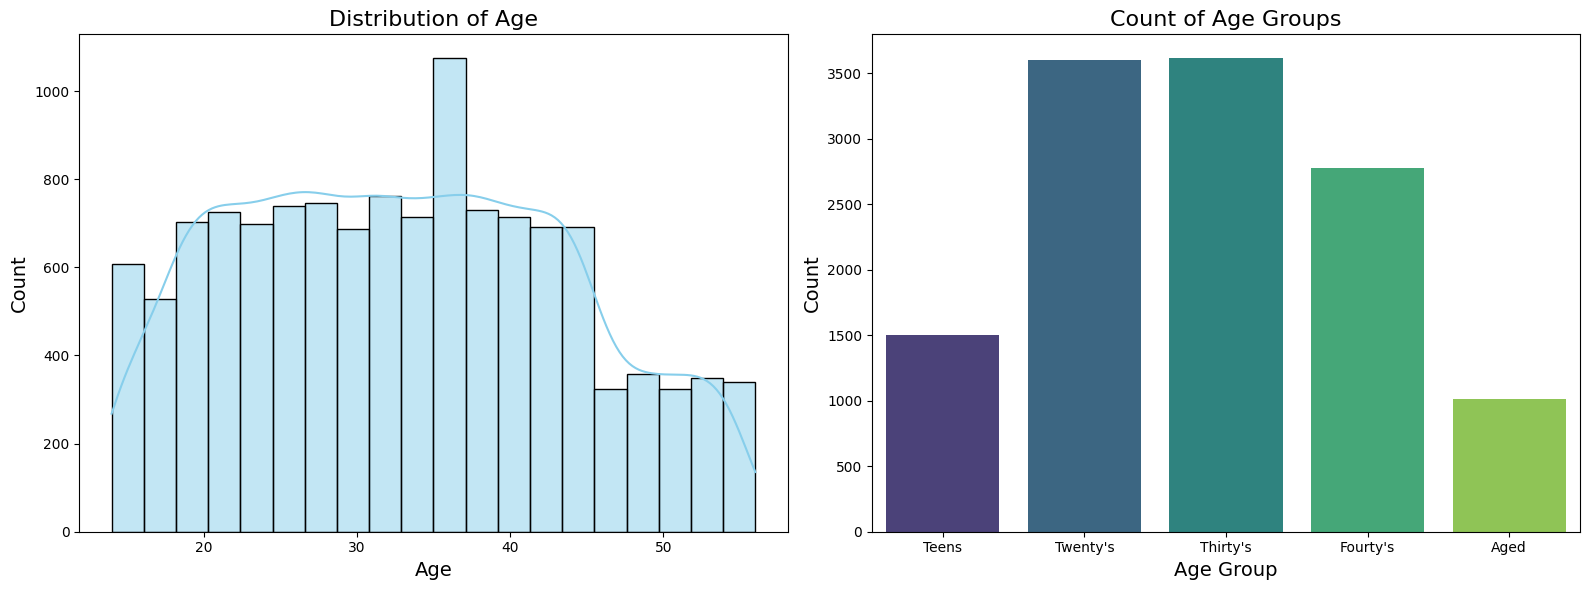

In [51]:
#histogram of "Age" column and count plot of "Age_Group" column

#intilizing the figure size
fig, ax = plt.subplots(1, 2,figsize=(16,6))

#plotting the histogram of "Age" column with 20 bins and kde
sns.histplot(data=concise_df, x="Age", ax= ax[0], bins=20, kde=True, color="skyblue")

#customizing the plot
ax[0].set_title("Distribution of Age", fontsize=16)
ax[0].set_xlabel("Age", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14) 

# Define the desired order for Age_Group
age_order = ["Teens", "Twenty's", "Thirty's", "Fourty's", "Aged"]

#plotting the count plot of "Age_Group" column
sns.countplot(data=concise_df, x="Age_Group", ax=ax[1], palette="viridis", order=age_order) 
#customizing the count plot
ax[1].set_title("Count of Age Groups", fontsize=16) 
ax[1].set_xlabel("Age Group", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Histogram show the distrabution of values and their frequency. In this context I want see distrabution of age. which aged people are more likely to take Credt card.
Count plot plots the number observation of every catogery in that column.Here I added a column which is catogerized by age and plot a count plot on it. so, that we can get better estimation of count of customers.

##### 2. What is/are the insight(s) found from the chart?

By analyzing both histogram and count plot we can say that age between 20 and 45 are more likely to take Credit card. so, studying their financial behaviour will give us important insights. 

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

From above charts one insight we can gain is studying financial behaviour of customer between age 20 and 45. which, will create postive impact on bussiness.

#### Pie Chart of Credit Card Distrabution(Univariate Analysis)

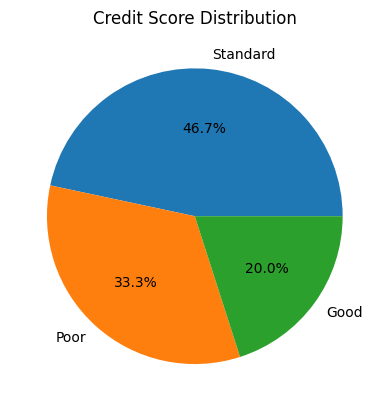

In [52]:
# pie chart of "Credit_Score" column

concise_df["Credit_Score"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Credit Score Distribution")
plt.ylabel("")  
plt.show()

##### 1. Why did you pick the specific chart?

Pie Chart is Used to visualize the percentage of catogery data. I want to see the propotion between Good, Standard and Poor Credit Scores

##### 2. What is/are the insight(s) found from the chart?

There are large percentage of people with Standard Credit aproximately 50 percentage of them are with Standard Credit Score and less percentage of people with good credit score

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It's important to know about our customers and their propotion to analyze our risk in bussiness it will definetely create postive impact.

#### Box Plot of Monthly Inhand Salary of each category of Credit Score(Bivariate Analysis)

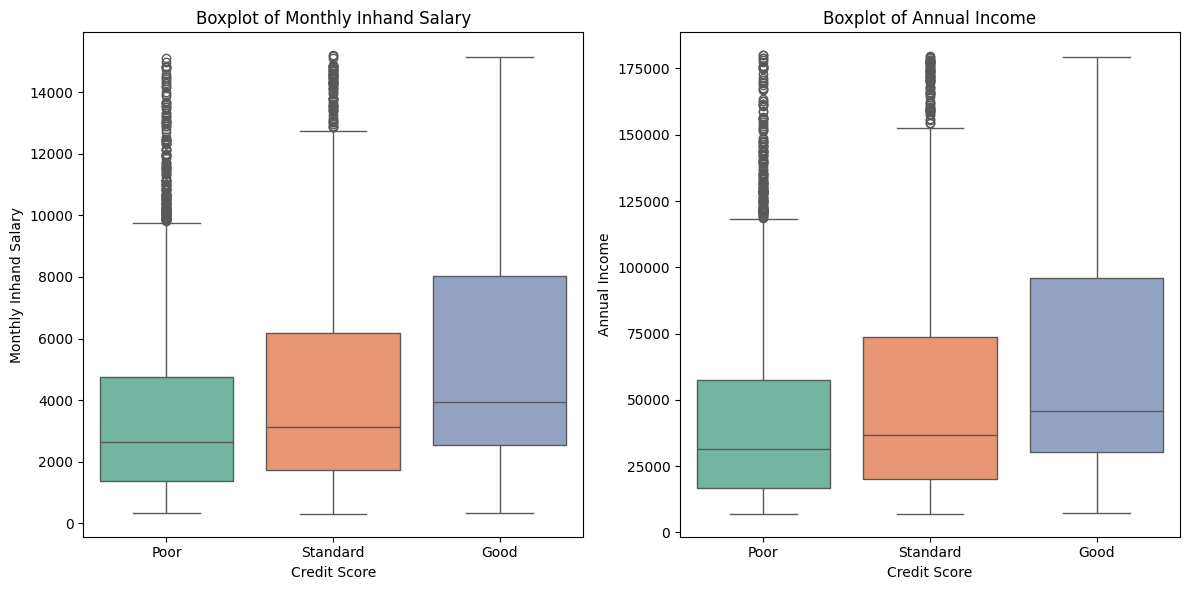

In [53]:
#Intilize the figure size for boxplots
fig, ax = plt.subplots(1, 2,figsize=(12, 6))

#Boxplots for Monthly Inhand Salary and Annual Income with respect to Credit Score
sns.boxplot(data=concise_df, y="Monthly_Inhand_Salary", x="Credit_Score", ax=ax[0], palette="Set2")

#customizing the boxplot
ax[0].set_title("Boxplot of Monthly Inhand Salary")
ax[0].set_xlabel("Credit Score")
ax[0].set_ylabel("Monthly Inhand Salary")

#Boxplot for Annual Income with respect to Credit Score
sns.boxplot(data=concise_df, y="Annual_Income", x="Credit_Score",ax = ax[1], palette="Set2")
#customizing the boxplot
ax[1].set_title("Boxplot of Annual Income")
ax[1].set_xlabel("Credit Score")
ax[1].set_ylabel("Annual Income")   
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

Boxplot shows Distrabution, Median, Quartiles and Outliers for numerical column. I want to see outliers 
of salary of each Credit Score category. 

##### 2. What is/are the insight(s) found from the chart?

- From above plots we can clearly say Median of salary is greter for person with good credit score than two other categories.
- people with standard credit score have better medain of  salary than people with poor credit score.
- There are outlier in standard and poor credit score distrabution of salary.
- That means not every one who have high salary tend to have Good credit score



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

We should keep in mind that not every one with good salary have good credit score and we should not depend on one  to analyze  risk  that might lead to negative growth of bussiness, we should consider multiple factors to analyze the risk.

#### Bar Graph of Average Number of Bank Accounts by Credit Score(Bivariate Analysis)

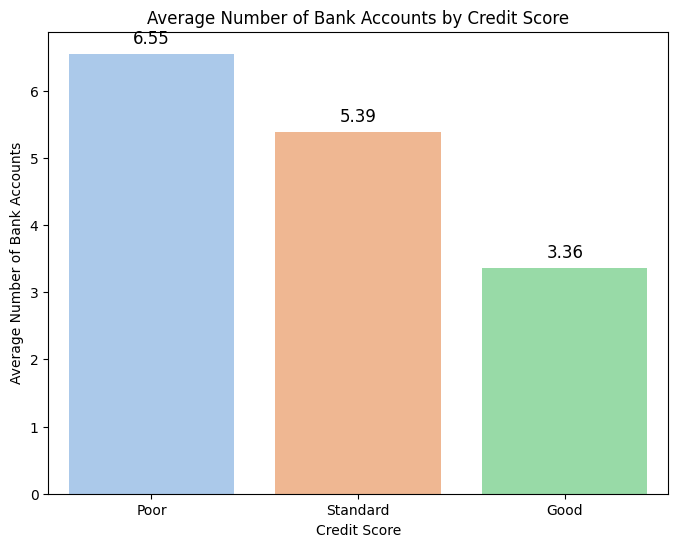

In [54]:
#Intilize the figure size for barplot
plt.figure(figsize=(8, 6))

#Barplot for Average Number of Bank Accounts by Credit Score
sns.barplot(data=concise_df, x="Credit_Score", y="Num_Bank_Accounts", palette="pastel", ci=None)

#Printing the Average Number of Bank Accounts by Credit Score
avg_bank_accounts = concise_df.groupby("Credit_Score")["Num_Bank_Accounts"].mean().sort_values(ascending=False)

for i, value in enumerate(avg_bank_accounts):
    plt.text(i, value + 0.1, f"{value:.2f}", ha="center", va="bottom", fontsize=12)

#customizing the barplot
plt.title("Average Number of Bank Accounts by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Average Number of Bank Accounts")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is used to visualize the categorical data. I want to see realtionship between bank accounts and credit score so, i choose bar chart to visualize average number of bank account to each category.

##### 2. What is/are the insight(s) found from the chart?

- From above chart we can clearly see Poor credit score persons have above  six bank accounts on average.
- where as standard credit score people have 5 bank accounts on average and good credit score people have less than 4 bannk accounts.
- So, Increase in bank account leads to poor credit card score.
- It's a risk offering a lone or credit score those who have more than 6 bank accounts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Increase in Bank account leads to poor credit card score which is negative growth. One main reason it leads to poor credit score is as we tend to have many bank account people tend to take more loans and credit cards from that bank which is hard to manage or pay that back.

Answer Here

#### Bar Graph of Age group vs their percentage in specific category(Bivariate Analysis)

  Age_Group  Good Credit Score %
0     Teens            10.747664
1  Twenty's            18.065592
2  Thirty's            18.810512
3  Fourty's            22.658501
4      Aged            38.104640


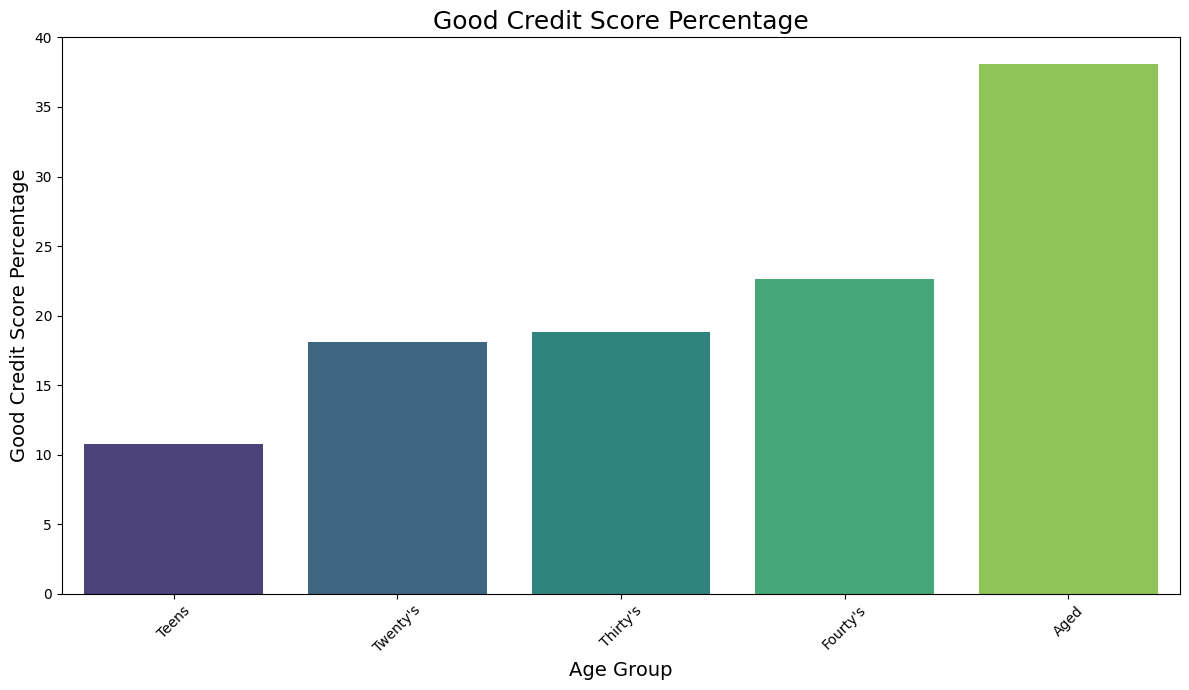

In [55]:
# Bar chart:  Highest Percentage of Good Credit Score

# Calculate percentage of 'Good' credit score for each age group
agegroup_good_pct = (
    concise_df.groupby('Age_Group')['Credit_Score']
    .apply(lambda x: (x == 'Good').mean() * 100)
    .sort_values()
    .reset_index(name='Good Credit Score %')
)

# Show  Age Group with Highest Percentage of Good Credit Score
print(agegroup_good_pct)

# Plot the bar chart

plt.figure(figsize=(12, 7))
sns.barplot(
    data=agegroup_good_pct,
    x='Age_Group',
    y='Good Credit Score %',
    palette='viridis'
)
plt.title("Good Credit Score Percentage", fontsize=18)
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Good Credit Score Percentage", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  Age_Group  Standard Credit Score %
0     Teens                43.925234
1  Thirty's                46.168741
2  Twenty's                46.442468
3  Fourty's                47.982709
4      Aged                49.555775


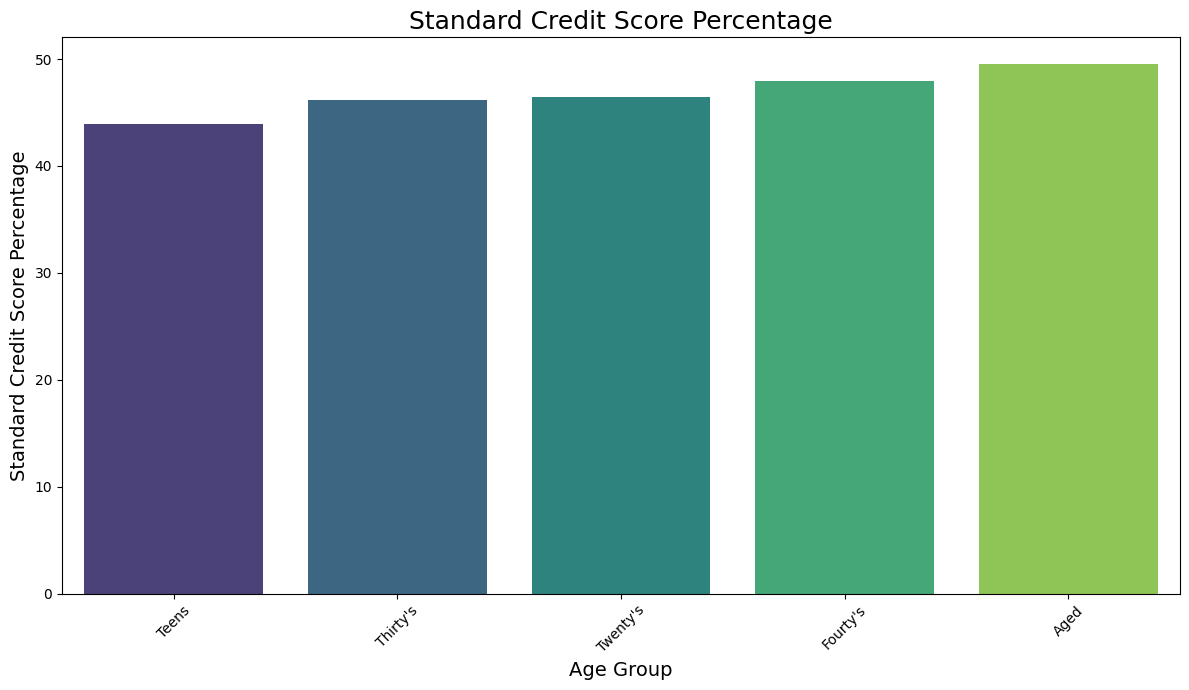

In [56]:
# Bar chart:  Highest Percentage of Standard Credit Score

# Calculate percentage of 'Standard' credit score for each age group
agegroup_good_pct = (
    concise_df.groupby('Age_Group')['Credit_Score']
    .apply(lambda x: (x == 'Standard').mean() * 100)
    .sort_values()
    .reset_index(name='Standard Credit Score %')
)

# Show  Age Group with Highest Percentage of Standard Credit Score
print(agegroup_good_pct)

#Intilize the figure size for bar chart
plt.figure(figsize=(12, 7))

# Plotting the bar chart for Standard Credit Score Percentage
sns.barplot(
    data=agegroup_good_pct,
    x='Age_Group',
    y='Standard Credit Score %',
    palette='viridis'
)
#customizing the bar chart
plt.title("Standard Credit Score Percentage", fontsize=18)
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Standard Credit Score Percentage", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

  Age_Group  Poor Credit Score %
0     Teens            45.327103
1  Twenty's            35.491940
2  Thirty's            35.020747
3  Fourty's            29.358790
4      Aged            12.339585


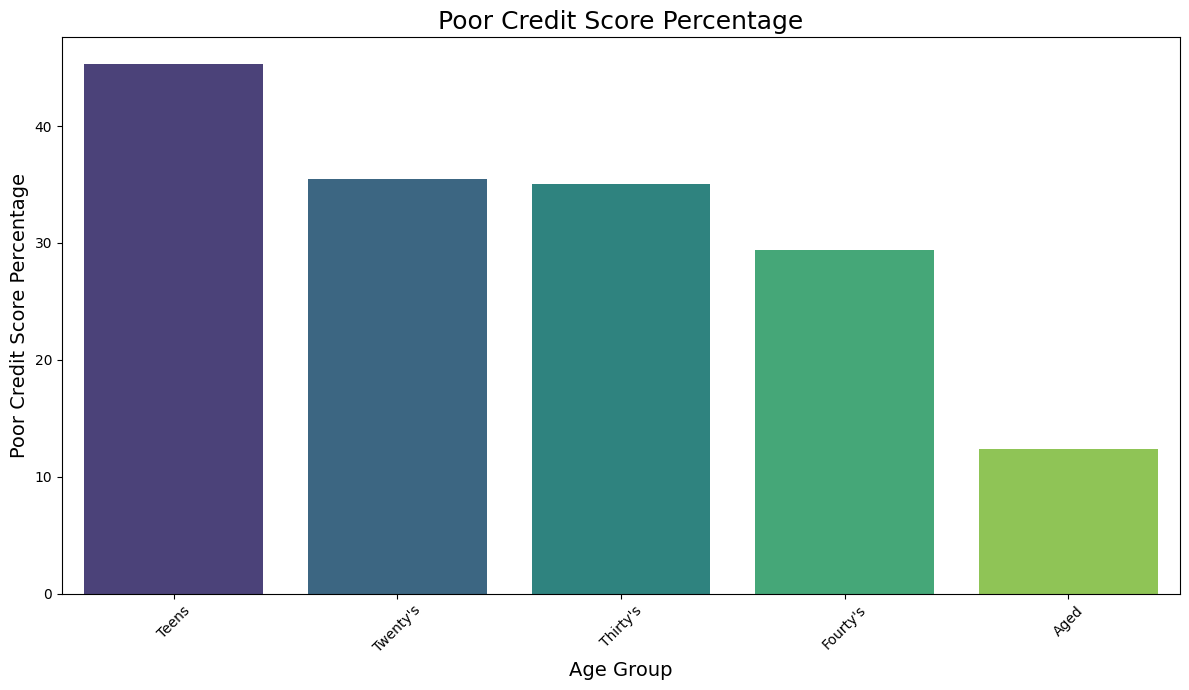

In [57]:
# Calculate percentage of 'Poor' credit score for each age group
agegroup_good_pct = (
    concise_df.groupby('Age_Group')['Credit_Score']
    .apply(lambda x: (x == 'Poor').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='Poor Credit Score %')
)

# Show  Age Group with Highest Percentage of Poor Credit Score
print(agegroup_good_pct)

# Plot the bar chart

plt.figure(figsize=(12, 7))
sns.barplot(
    data=agegroup_good_pct,
    x='Age_Group',
    y='Poor Credit Score %',
    
    palette='viridis'
)
plt.title("Poor Credit Score Percentage", fontsize=18)
plt.xlabel("Age Group", fontsize=14)
plt.ylabel("Poor Credit Score Percentage", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar Graph is ideal for visualizing Categorical data and for comparing the percentage of different aged group people acroos different category. Bar plots clearly display differences between categories, making it easy to identify which age group have higher or lower proportions of each category credit scores.

##### 2. What is/are the insight(s) found from the chart?

**Good credit Score Percentage**
- In the first Good credit score percentage chart we can clearly see Aged which are above 40 years  people Dominated chart with 39 percenrage.
- Only 10 percentage of teens have good credit score which is very less
- fourty's have little better percentage than thirty's and twenty's.
- percentage increased with the age.



**Standard credit score percentage**
- In the second Standard credit score percentage chart almost every individual age group have above 40 percentage of that group have standard credit score
- large percentage of people are in standard category in every individual group.
- Aged group have large percentage.


**Poor credit score percentage**
- In the third Poor standard credit score percentage we can see  percentage of teens have poor credit score.
- Aged people are less percentage in poor credit score.
- percentage decresed with the age.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- From above insights we can clearly say that with increase in age they tends to have good credit score. if we offer credit card to people who have people aged people we have very less risk. but, with teen we have high percentage of risk.

#### Annual income vs Age line chart(Bivariate Analysis)

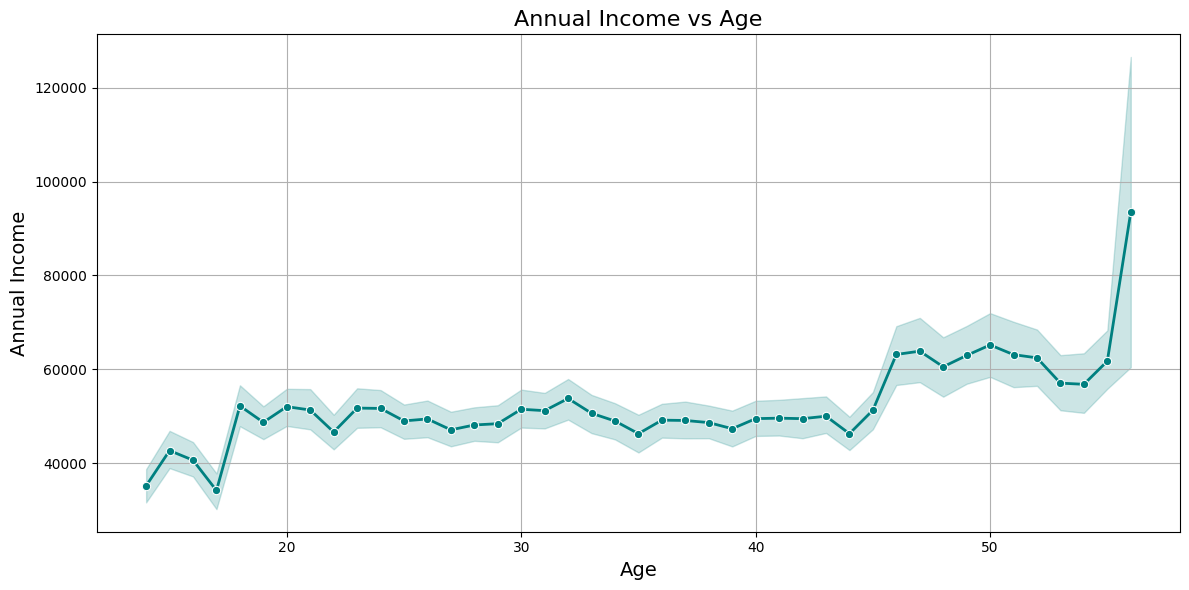

In [58]:
# Line chart for Anuual Income to Age.
plt.figure(figsize=(12, 6))

# Create a line plot for Annual Income vs Age
sns.lineplot(data=concise_df, x="Age", y="Annual_Income",marker= "o", color="teal", linewidth=2)

# Customizing the plot
plt.title("Annual Income vs Age", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Annual Income", fontsize=14)

plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line plot shows relationship between two Numerical columns.I want to see relationship between Annual Income and Age which are two numerical columns.So, Line plot is perfect to shows how Annual Income changes with Age.

##### 2. What is/are the insight(s) found from the chart?

- Annual income increses with Age which is what I excpected to be. Annual income of age above 45 have above 60,000.
- But, there is lot of inconsistencies in between 20 to 45 age group. which need to be studies indetail with other factors. 
- Teens have less than 50000 annual Income.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

From previous charts and this chart we can come to one conclusion that Age, Annual Income and Credit score are Inter related and directly prapotional to each other. With Age Annual income increse so does Credit score. But, age between 25 to 45 need more attention and analyse another factors too to get more Insights.which might create postive business impact.
 

#### BoxPlot of changed credit limit with respect to Credit Score(Bivarate Analysis)

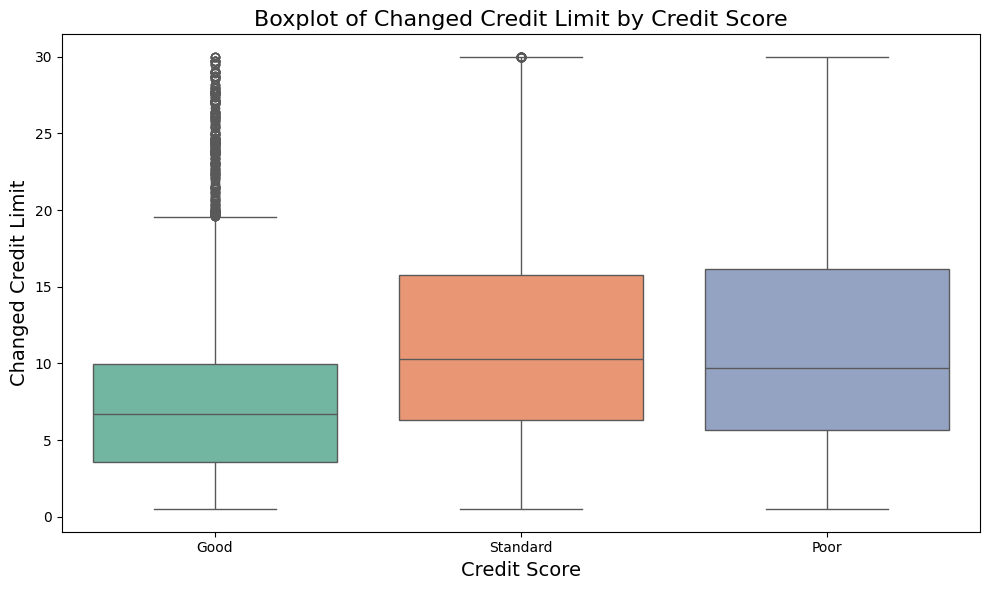

In [59]:
# BoxPlot of changed credit limit with respect to credit score
plt.figure(figsize=(10, 6))

# Create a boxplot for Changed Credit Limit by Credit Score
sns.boxplot(data=df, x="Credit_Score", y="Changed_Credit_Limit", palette="Set2")

# Customizing the plot
plt.title("Boxplot of Changed Credit Limit by Credit Score", fontsize=16)
plt.xlabel("Credit Score", fontsize=14) 
plt.ylabel("Changed Credit Limit", fontsize=14)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Boxplot is best to visualize betweeen Numerical data and categorical data. It shows Distrabution, Median, Quartiles and Outliers for numerical column. Here I want to see relation between Changed Credit Limit which is numerical column and Credit Score which is categorical column.

##### 2. What is/are the insight(s) found from the chart?

- The Median of changed credit limit of Good credit score is aroun 7 which is less than Standard and Poor.
- But, there are many outlier in godd credit score distrabution.
- there is no specific relation when we see poor and standard.
- May be Changed credit limit has very less effect on credit score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

There no better insight from above to create postive impact in bussiness.

#### Histogram distribution of Total_EMI_per_month for each Credit Score Category(Univarient)

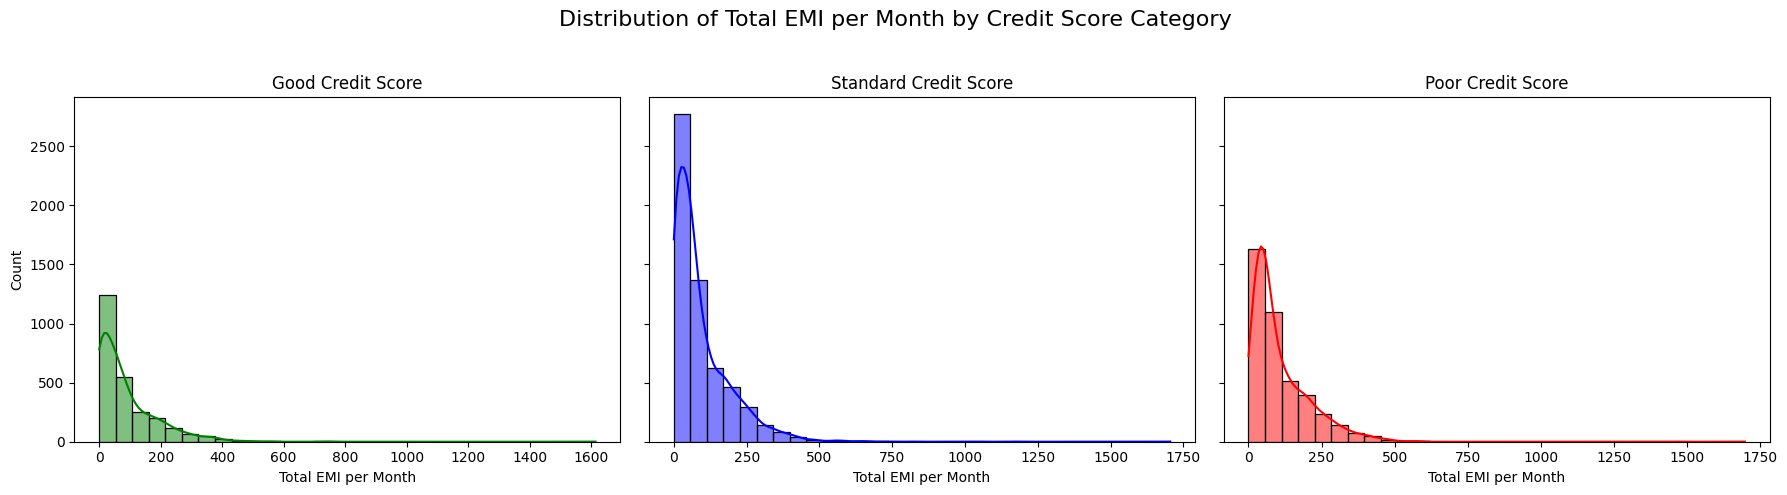

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot for Good Credit Score
sns.histplot(good_df["Total_EMI_per_month"], bins=30, kde=True, color="green", ax=axes[0])
axes[0].set_title("Good Credit Score")
axes[0].set_xlabel("Total EMI per Month")
axes[0].set_ylabel("Count")

# Plot for Standard Credit Score
sns.histplot(standard_df["Total_EMI_per_month"], bins=30, kde=True, color="blue", ax=axes[1])
axes[1].set_title("Standard Credit Score")
axes[1].set_xlabel("Total EMI per Month")

# Plot for Poor Credit Score
sns.histplot(poor_df["Total_EMI_per_month"], bins=30, kde=True, color="red", ax=axes[2])
axes[2].set_title("Poor Credit Score")
axes[2].set_xlabel("Total EMI per Month")

plt.suptitle("Distribution of Total EMI per Month by Credit Score Category", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [61]:
# Median of Total EMI per month for each Credit Score category
concise_df.groupby("Credit_Score")["Total_EMI_per_month"].median().sort_values(ascending=False).reset_index(name="Total_EMI_per_month_Median")

,Credit_Score,Total_EMI_per_month_Median
0,Poor,72.926801
1,Standard,60.811743
2,Good,55.074473


##### 1. Why did you pick the specific chart?

Histplot is to veiw distrabution of numerical column. I want to know distrabution of total EMI of each category and see how the distarbution is spread.

##### 2. What is/are the insight(s) found from the chart?

- The Distrabution of Total EMI per Month for each credit score category is right-skewed(Postiviely Skewed).
- This means most customers have lower EMI amounts, while a smaller number have much higher EMIs, creating a long tail to the right in each histogram.
- Finding the median is appropriate for right-skewed distributions like Total EMI per Month.
- People with more than 72 total emi per month have  poor credit score,  and greater than 60.8 total emi per month have standard credit score
- good credit people have less than 55 emi per month.
- risk increses with the increse in total Emi per Month.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The median is less affected by extreme values (outliers) than the mean, so it gives a better representation of the "typical" EMI amount for each credit score group.
This helps the business understand what most customers are likely to pay, rather than being influenced by a few customers with very high EMIs these, insights can help create a positive business impact.

#### Count Plot between Payment_Behaviour and Credit_Score(Bivarate Analysis)

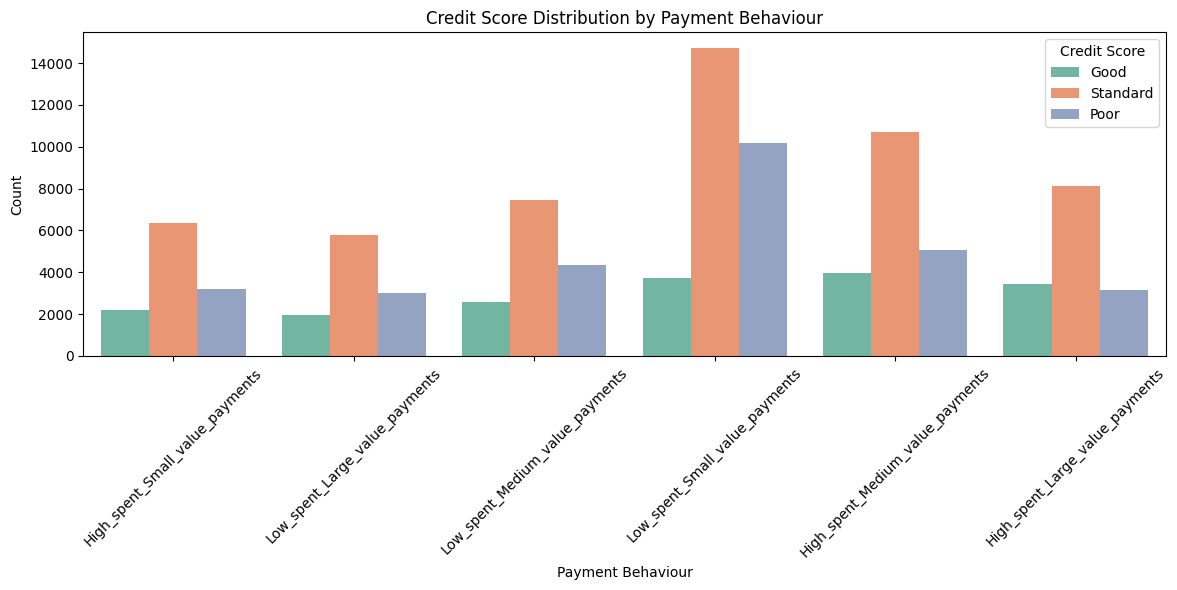

In [62]:
# intilizing the figure size for countplot
plt.figure(figsize=(12, 6))

# Countplot for Payment Behaviour by Credit Score
sns.countplot(data=df, x="Payment_Behaviour", hue="Credit_Score", palette="Set2")

# Customizing the plot
plt.title("Credit Score Distribution by Payment Behaviour")
plt.xlabel("Payment Behaviour")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Credit Score")
plt.tight_layout()
plt.show()

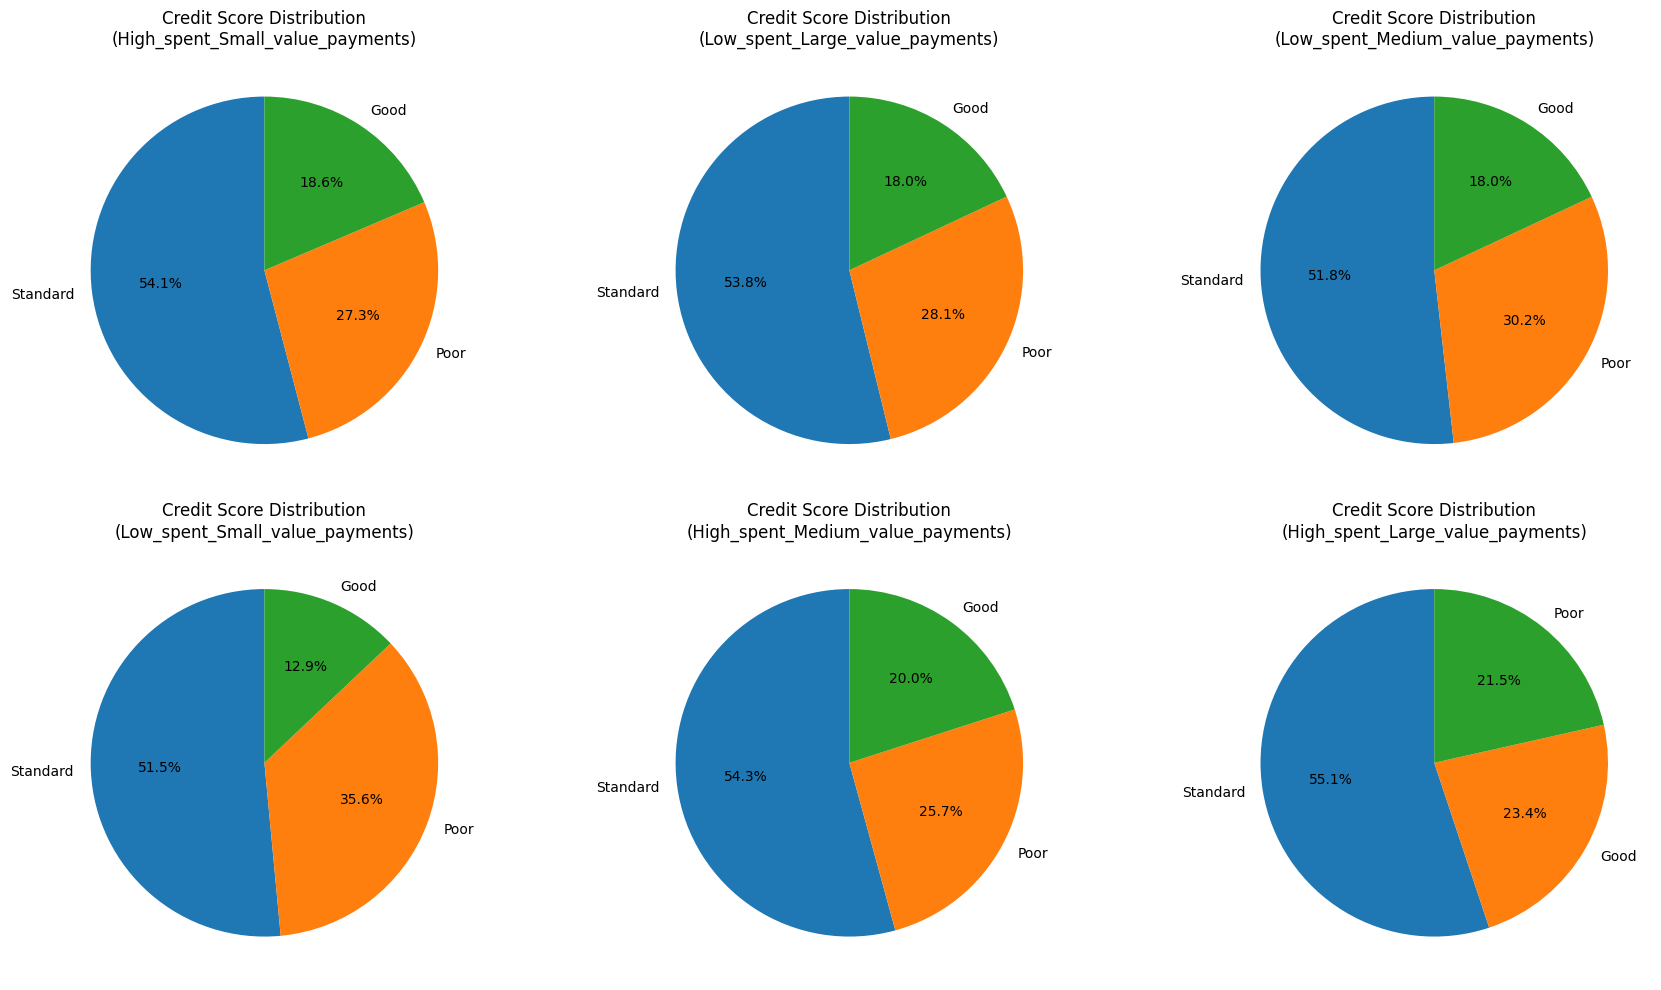

In [63]:
# Pie charts for percentage of each Credit Score category within each Payment Behaviour

payment_behaviour_list = df['Payment_Behaviour'].unique()

# Intilize the figure size for pie charts and subplots
fig, axes = plt.subplots(
    nrows=int(np.ceil(len(payment_behaviour_list) / 3)), ncols=3, 
    figsize=(18, int(5 * np.ceil(len(payment_behaviour_list) / 3)))
)
# Flatten the axes array for easier iteration
axes = axes.flatten()

# Create pie charts for each Payment Behaviour using for loop
for i, behaviour in enumerate(payment_behaviour_list):

    # Get the counts of Credit Score for the current Payment Behaviour
    counts = df[df['Payment_Behaviour'] == behaviour]['Credit_Score'].value_counts()

    # Create a pie chart for the current Payment Behaviour
    axes[i].pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=sns.color_palette('tab10', n_colors=3)
    )
    axes[i].set_title(f'Credit Score Distribution\n({behaviour})')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

 A count plot is ideal for visualizing the relationship between two categorical variables, such as Payment_Behaviour and Credit_Score. It clearly shows the distribution and frequency of each payment behaviour across different credit score categories, making it easy to compare patterns and identify which behaviours are associated with good, standard, or poor credit scores.

 A pie chart because it is great to visualize percentage. I want to see percentage of each credit score percenatge in the specific category and get more clarity on payment behaviour.

##### 2. What is/are the insight(s) found from the chart?

Almost all payment behaviour categories have similar percentages of Good, Standard, and Poor credit scores. This suggests that Payment_Behaviour has very little correlation with credit score in this dataset. No specific payment behaviour stands out as being strongly associated with either high or low credit scores, indicating that other factors may play a more significant role in determining  creditworthiness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights from this analysis suggest that Payment_Behaviour does not have a strong correlation with credit score, as almost all payment behaviour categories have similar percentages of Good, Standard, and Poor credit scores. This is a positive business insight because it helps the company avoid focusing on less relevant features when assessing credit risk. Instead, resources can be directed toward more impactful variables.



#### Bar chart of Average Number of Credit Cards by Credit Score(Bivariate Analysis)

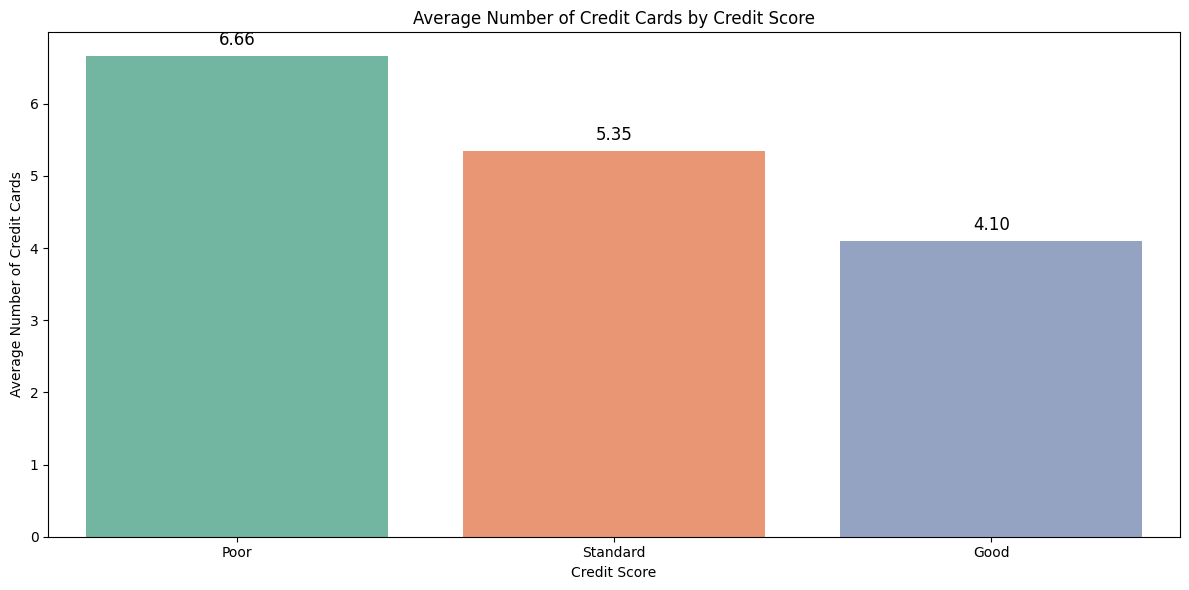

In [64]:
# Bar chart for avg Credit Card by credit card
plt.figure(figsize=(12, 6))
sns.barplot(data=concise_df, x="Credit_Score", y="Num_Credit_Card", palette="Set2", ci=None)
plt.title("Average Number of Credit Cards by Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Average Number of Credit Cards")
# Calculate mean values for each Credit_Score category
means = concise_df.groupby("Credit_Score")["Num_Credit_Card"].mean().sort_values(ascending=False)

# Add mean values on top of each bar
for i, mean in enumerate(means):
    plt.text(i, mean + 0.1, f"{mean:.2f}", ha='center', va='bottom', fontsize=12)

plt.tight_layout()  
plt.show()


##### 1. Why did you pick the specific chart?

Bar chart is used to visualize the categorical data. I want to see realtionship between Number of credit cards and credit score so, i choose bar chart to visualize average number of bank account to each category.

##### 2. What is/are the insight(s) found from the chart?

- persons who have more than 6 credit cards tends to have poor credit score.
- good credit score have less than 4 credit card.
- with increse in credit cards the credit score leads to poor credit score.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. By identifying that customers with more than 6 credit cards are more likely to have poor credit scores, financial institutions can set stricter lending criteria or offer targeted financial advice to such customers, reducing the risk of defaults.

#### Boxplot of Amount Invested Monthly by Credit Card(Bivarient Analysis)

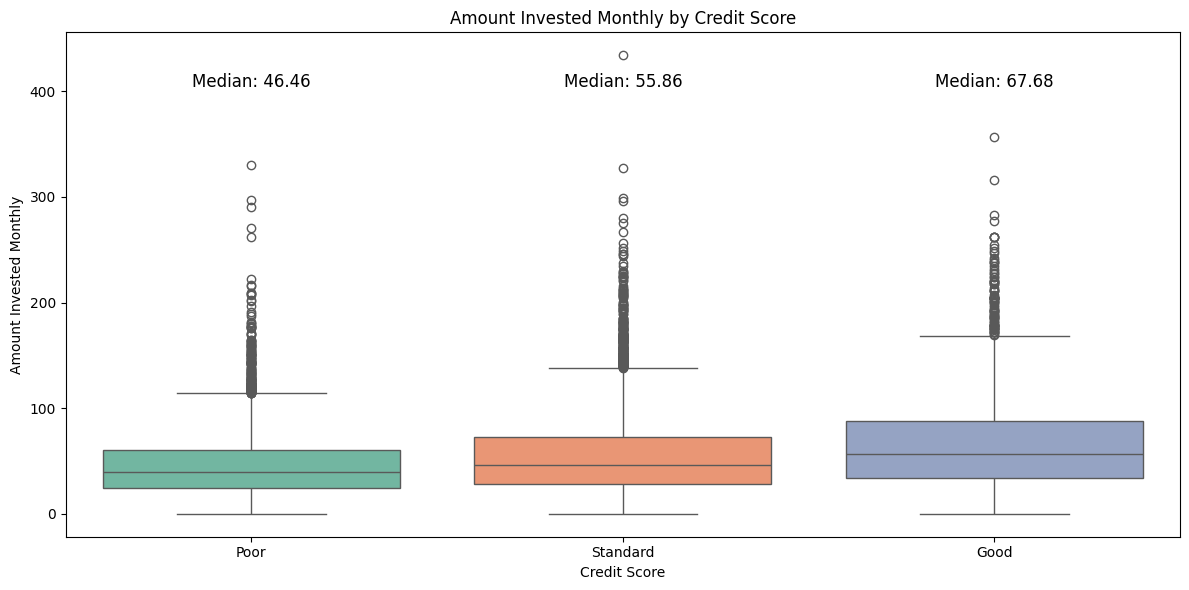

In [65]:
# Add mean values on top of each bar
medians = concise_df.groupby("Credit_Score")["Amount_invested_monthly"].mean().sort_values().reset_index(name="Average_Amount_invested_monthly")


#Box plot for Average Amount Invested Monthly by Credit Score
plt.figure(figsize=(12, 6))
sns.boxplot(data=concise_df, x="Credit_Score", y="Amount_invested_monthly", palette="Set2")

# Adding median values on top of each box
plt.text(0, 400, f"Median: {medians['Average_Amount_invested_monthly'][0]:.2f}", ha='center', va='bottom', fontsize=12)
plt.text(1, 400, f"Median: {medians['Average_Amount_invested_monthly'][1]:.2f}", ha='center', va='bottom', fontsize=12)
plt.text(2, 400, f"Median: {medians['Average_Amount_invested_monthly'][2]:.2f}", ha='center', va='bottom', fontsize=12)

# Customizing the boxplot
plt.title("Amount Invested Monthly by Credit Score")
plt.xlabel("Credit Score") 
plt.ylabel("Amount Invested Monthly")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box Plot is ideal for visualisation of distrabution, median and outliers of data. Since I want to compare numeric and  category column it is best way to visualise distrabution of that data along with outlier and median.

##### 2. What is/are the insight(s) found from the chart?

- we can see distrabution of each category id right-skewed postively skewed.
- So, median is proper computation to compare as it is lees effected by extrem values.
- Good credit score people are investing amount monthly greater than other category.
- Poor credit score people invest less amount monthly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. By identifying that customers with good credit scores tend to invest more monthly, Paisabazaar can target and prioritize such customers for premium financial products. Conversely, recognizing that poor credit score customers invest less can help the business design tailored financial advice or products to encourage better financial habits, potentially improving their creditworthiness and reducing risk for the company.

#### Bar Chart of Number loans by Credit Score(Bivarient Analysis)

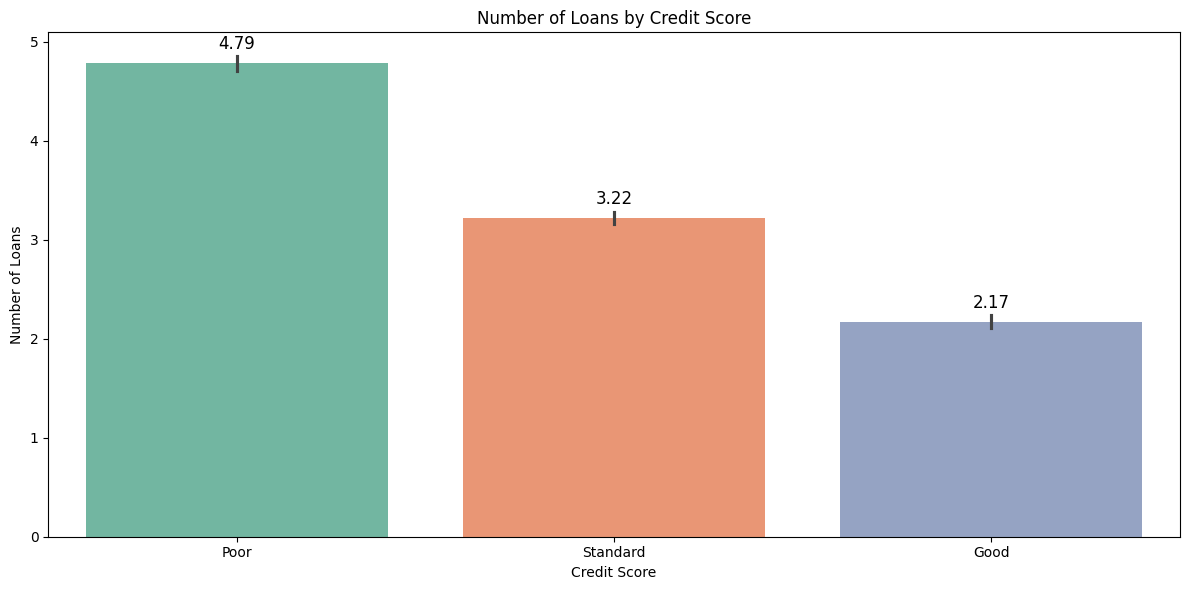

In [66]:
#Bar Chart for Num of Loans by Credit Score
plt.figure(figsize=(12, 6))
sns.barplot(data=concise_df, x="Credit_Score", y="Num_of_Loan", palette="Set2")
# Adding mean values on top of each bar
means = concise_df.groupby("Credit_Score")["Num_of_Loan"].mean().sort_values(ascending=False)
for i, mean in enumerate(means):
    plt.text(i, mean + 0.1, f"{mean:.2f}", ha='center', va='bottom', fontsize=12)
# Customizing the bar chart
plt.title("Number of Loans by Credit Score")    
plt.xlabel("Credit Score")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts are ideal for comparing the average values of a numerical variable across different categories. Here, we want to compare the average number of loans for each credit score group (Good, Standard, Poor), so a bar chart makes it easy to visualize and compare these differences.

##### 2. What is/are the insight(s) found from the chart?

- Customers with poor credit scores tend to have a higher average number of loans.
- Good credit score customers have the lowest average number of loans.
- As the number of loans increases, the likelihood of having a poor credit score also increases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. By identifying that customers with more loans are more likely to have poor credit scores, Paisabazaar can adjust its risk assessment strategies, set stricter lending criteria, or offer financial counseling to customers with multiple loans. This can help reduce default risk and improve overall portfolio quality. However, if the business ignores this insight and continues to offer loans to customers with many existing loans, it could lead to increased defaults and negative growth.

####  Correlation Heatmap

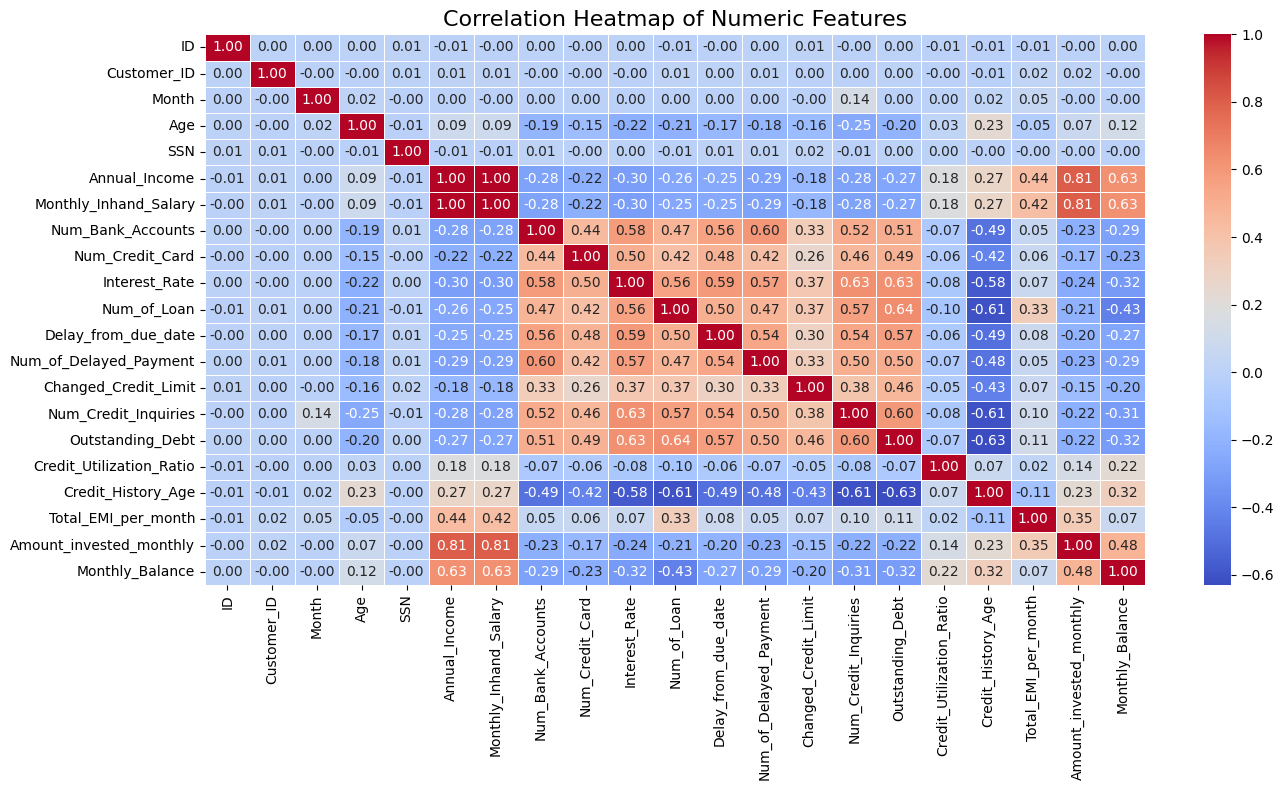

In [68]:
# selecting numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number])

# Intilizing the figure size for correlation heatmap
plt.figure(figsize=(14, 8))

# Calculating the correlation matrix
corr_matrix = numeric_cols.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

We picked a heatmap because it visually displays the correlation between multiple numerical variables in a single, easy-to-read chart. This helps quickly identify which features are strongly or weakly related to each other, making it easier to spot patterns, trends, or potential predictors for credit score. The color gradients in a heatmap make it simple to interpret the strength and direction of correlations at a glance.

##### 2. What is/are the insight(s) found from the chart?

- Amount Invested monthly has strong postive correlation with Annual Income which have strong postive relation with credit score.
- Even Monthly Balnce has good postive correlation with Annual Income.
- Credit history has  negative relationship with Number of Loans,number of credit enquire and outstanding debtss. 

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To achieve the bussiness objective, I suggest Paisabazar should focus on the following actions based on the analysis:

- Customers with higher annual incomes, fewer bank accounts, fewer loans and fewer credit cards should their priority because as this factors associated with good credit scores which involves less risk.
- customer with high EMI per month and high outstanding debt and high intrest rate are tend to have poor credit score so, they need pay special attention to this customers to reduce risk.
- Use age and income as key features in credit assessment models, since older customers with higher income tend to have better credit scores.

- Don't give credit card or Loan with high intrest rates as they are more likely to have poor credit score.

- Offer targeted financial advice and products to high-risk groups (e.g., younger customers, those with many credit cards or bank accounts) to help them improve their creditworthiness.

By implementing these strategies, Paisabazaar can enhance its credit assessment process, reduce financial risk, and provide better recommendations to its customers.


# **Conclusion**

After conducting a comprehensive exploratory data analysis on Paisabazaar’s customer dataset, several key insights were uncovered regarding the factors that influence credit scores. The analysis revealed that higher annual income, fewer bank accounts,fewer loans and fewer credit cards are strongly associated with good credit scores, while high outstanding debt, high EMI per month, and high interest rates are linked to poor credit scores. Age and income emerged as significant predictors, with older and higher-income customers tending to have better credit scores.

Additionally, some factors like occupation and payment behaviour showed little correlation with credit score, allowing the business to focus on more impactful variables for risk assessment. By leveraging these insights, Paisabazaar can refine its credit assessment process, reduce financial risk, and provide more targeted financial products and advice to its customers. Overall, data-driven decision-making will help Paisabazaar enhance customer satisfaction and achieve sustainable business growth.